In [1]:
#install imblearn
!pip install imblearn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/healthcare-dataset-stroke-data (1).csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [7]:
jumlah_baris_asli = df.shape[0]
missing_bmi_asli = df['bmi'].isnull().sum()
missing_glucose_asli = df['avg_glucose_level'].isnull().sum()
jumlah_duplikat = df.duplicated().sum()

if jumlah_duplikat > 0:
    df.drop_duplicates(inplace=True)

cols_to_check = ['bmi', 'avg_glucose_level']
for col in cols_to_check:
    df[col] = df[col].fillna(df[col].median())

kolom_kategori = ['gender', 'smoking_status']
for col in kolom_kategori:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip()

# --- D. Handling Outliers menggunakan Metode IQR Capping & Menghitung Jumlahnya ---
total_outliers = 0
num_cols = ['age', 'bmi', 'avg_glucose_level']
dict_outliers = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Hitung jumlah pencilan asli yang beneran ada di data kamu saat ini
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    dict_outliers[col] = outlier_count
    total_outliers += outlier_count

    # Eksekusi pangkas outlier (Capping)
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])


df.to_csv('stroke_data_hanya_cleaning.csv', index=False)
print("💾 File 1: 'stroke_data_hanya_cleaning.csv' BERHASIL DISIMPAN!\n")


💾 File 1: 'stroke_data_hanya_cleaning.csv' BERHASIL DISIMPAN!



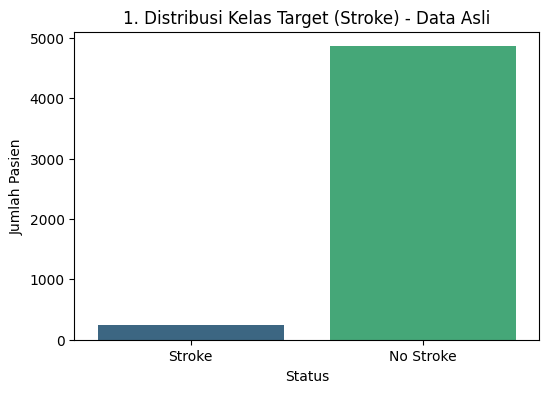

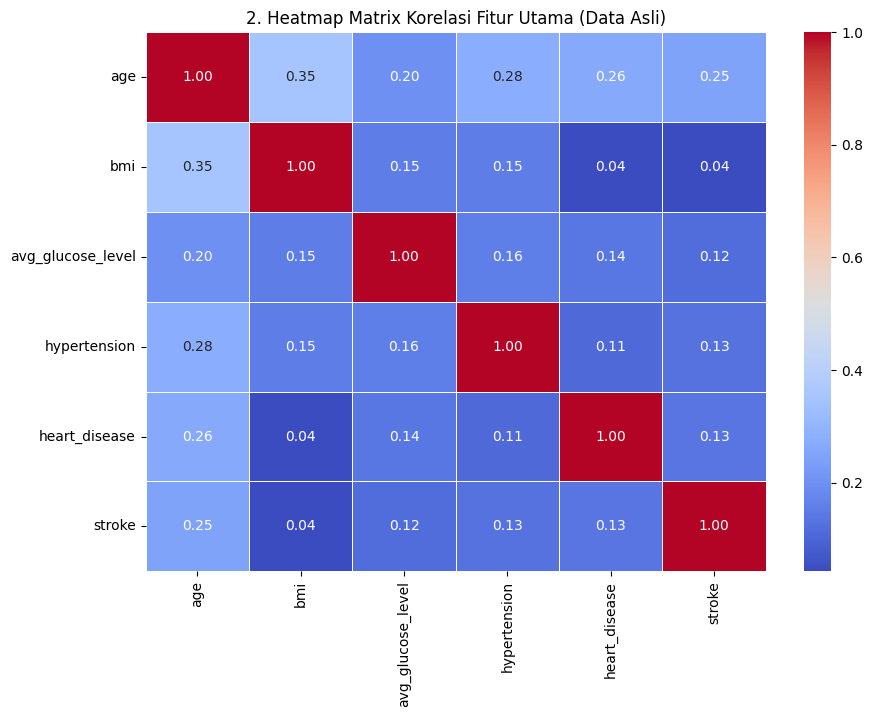

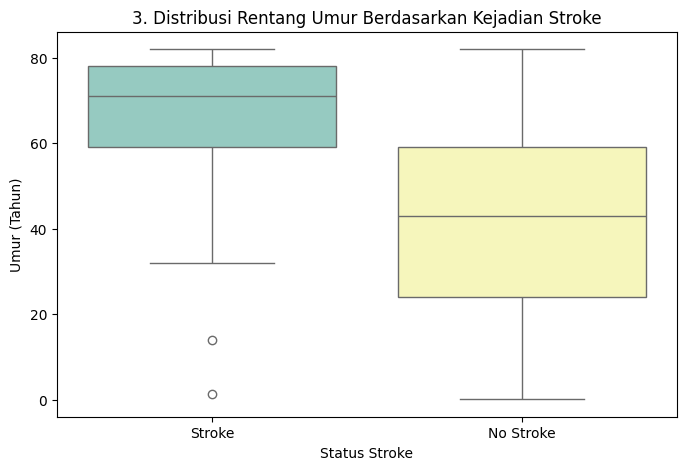

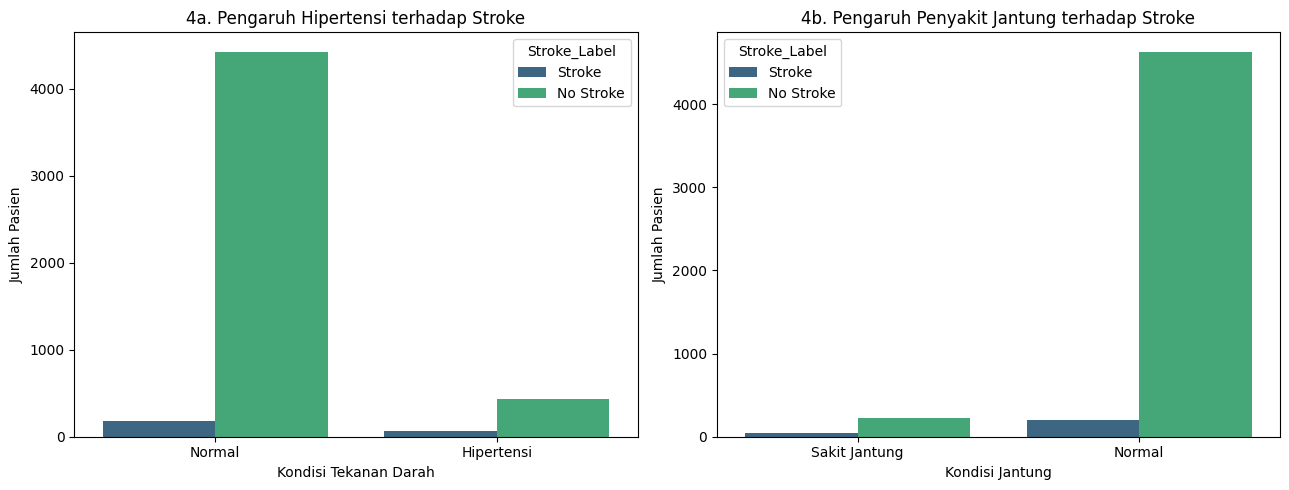

In [8]:
df_vis = df.copy()
df_vis['Stroke_Label'] = df_vis['stroke'].map({1: 'Stroke', 0: 'No Stroke'})
df_vis['Hypertension_Label'] = df_vis['hypertension'].map({1: 'Hipertensi', 0: 'Normal'})
df_vis['Heart_Disease_Label'] = df_vis['heart_disease'].map({1: 'Sakit Jantung', 0: 'Normal'})

# Grafik 1: Distribusi Imbalance Target
plt.figure(figsize=(6, 4))
sns.countplot(x='Stroke_Label', data=df_vis, palette='viridis')
plt.title('1. Distribusi Kelas Target (Stroke) - Data Asli')
plt.xlabel('Status')
plt.ylabel('Jumlah Pasien')
plt.show()

# Grafik 2: Heatmap Korelasi
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[['age', 'bmi', 'avg_glucose_level', 'hypertension', 'heart_disease', 'stroke']].corr(), # Changed column names to lowercase and 'avg_glucose' to 'avg_glucose_level'
    annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5
)
plt.title('2. Heatmap Matrix Korelasi Fitur Utama (Data Asli)')
plt.show()

# Grafik 3: Distribusi Umur Berdasarkan Stroke
plt.figure(figsize=(8, 5))
sns.boxplot(x='Stroke_Label', y='age', data=df_vis, palette='Set3') # Changed 'Age' to 'age'
plt.title('3. Distribusi Rentang Umur Berdasarkan Kejadian Stroke')
plt.xlabel('Status Stroke')
plt.ylabel('Umur (Tahun)')
plt.show()

# Grafik 4: Komorbiditas Hipertensi & Sakit Jantung
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(x='Hypertension_Label', hue='Stroke_Label', data=df_vis, ax=axes[0], palette='viridis')
axes[0].set_title('4a. Pengaruh Hipertensi terhadap Stroke')
axes[0].set_xlabel('Kondisi Tekanan Darah')
axes[0].set_ylabel('Jumlah Pasien')

sns.countplot(x='Heart_Disease_Label', hue='Stroke_Label', data=df_vis, ax=axes[1], palette='viridis')
axes[1].set_title('4b. Pengaruh Penyakit Jantung terhadap Stroke')
axes[1].set_xlabel('Kondisi Jantung')
axes[1].set_ylabel('Jumlah Pasien')
plt.tight_layout()
plt.show()


In [9]:
# Label Encoding untuk Gender
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

kolom_teks = ['ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Lakukan pengecekan agar tidak error jika ada kolom yang sudah tidak ada
kolom_ada = [col for col in kolom_teks if col in df.columns]

df = pd.get_dummies(df, columns=kolom_ada, drop_first=True)

# Konversi seluruh dataframe menjadi float agar kompatibel 100% dengan SMOTE di Pandas versi terbaru
df = df.astype(float)

scaler = MinMaxScaler()
num_cols = ['age', 'bmi', 'avg_glucose_level']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/healthcare-dataset-stroke-data (1).csv')
data = df.copy()
data.dropna(subset=['bmi'], inplace=True)
data.drop(columns=['id'], errors='ignore', inplace=True)

# Membuat ulang sistem skor
data['high_risk_score'] = 0
data.loc[data['hypertension'] == 1, 'high_risk_score'] += 1
data.loc[data['heart_disease'] == 1, 'high_risk_score'] += 1
data.loc[data['smoking_status'] == 'smokes', 'high_risk_score'] += 1
data.loc[data['avg_glucose_level'] >= 126.0, 'high_risk_score'] += 1
data.loc[data['bmi'] >= 25.0, 'high_risk_score'] += 1

def tentukan_level_risiko(skor):
    if skor >= 3: return 'High Risk'
    elif skor in [1, 2]: return 'Caution'
    else: return 'Low Risk'

# Inisialisasi Target Baru
data['risk_level'] = data['high_risk_score'].apply(tentukan_level_risiko)

X_mentah = data.drop(columns=['risk_level', 'high_risk_score', 'stroke'])

# Mengubah teks menjadi angka
X = pd.get_dummies(X_mentah, drop_first=True)

y = data['risk_level']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nDistribution Before SMOTE (y_train):")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nDistribution After SMOTE (y_train_smote):")
print(y_train_smote.value_counts())

model = RandomForestClassifier(random_state=42)
model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test)


Distribution Before SMOTE (y_train):
risk_level
Caution      2629
Low Risk      969
High Risk     329
Name: count, dtype: int64

Distribution After SMOTE (y_train_smote):
risk_level
Caution      2629
High Risk    2629
Low Risk     2629
Name: count, dtype: int64


In [23]:
import joblib

# Menyimpan model XGBoost atau Random Forest yang sudah dilatih
joblib.dump(model, 'model_stroke_risk.pkl')

# SANGAT PENTING: Simpan juga daftar kolom asli dari X_train Anda
# Ini berguna agar inputan user nanti urutan kolomnya tidak terbalik
kolom_training = X_train_smote.columns.tolist()
joblib.dump(kolom_training, 'kolom_training.pkl')

['kolom_training.pkl']

In [21]:
# Menampilkan tabel Confusion Matrix 3x3
tabel_hasil = confusion_matrix(y_test, y_pred)
tabel_df = pd.DataFrame(tabel_hasil,
                        columns=['Tebak Low', 'Tebak Caution', 'Tebak High'],
                        index=['Fakta Low', 'Fakta Caution', 'Fakta High'])

print("\nTabel Confusion Matrix (3x3):")
print(tabel_df)

print("\nLaporan Detail (Classification Report):")
print(classification_report(y_test, y_pred))

# Proses Inference
print("\n--- Berikut adalah proses inference Random Forest ---")

load_model = joblib.load('model_stroke_risk.pkl')
load_kolom = joblib.load('kolom_training.pkl') # Load the training columns

data_baru = pd.DataFrame({
    'gender': ["Male"],
    'age': [67],
    'hypertension': [1],
    'heart_disease': [1],
    'ever_married': ["Yes"],
    'work_type': ["Private"],
    'Residence_type': ["Urban"],
    'avg_glucose_level': [228.69],
    'bmi': [36.6],
    'smoking_status': ["formerly smoked"]
})


data_baru_processed = pd.get_dummies(data_baru, drop_first=True)

# Tambahkan Missing Colume jika ada
missing_cols = set(load_kolom) - set(data_baru_processed.columns)
for c in missing_cols:
    data_baru_processed[c] = 0

data_baru_processed = data_baru_processed[load_kolom]
prediksi = load_model.predict(data_baru_processed)
probabilitas = load_model.predict_proba(data_baru_processed)
kelas = load_model.classes_

print(f"Hasil Klasifikasi : {prediksi[0]}")
print("\n Detail Probabilitas: ")

for i, label in enumerate(kelas):
    persen = probabilitas[0][i] * 100
    print(f"- {label:<12}: {persen:>6.2f}%")

# Memberikan rekomendasi sederhana berdasarkan hasil
if prediksi[0] == 'High Risk':
    print("\nREKOMENDASI: Segera konsultasi dengan dokter spesialis.")
elif prediksi[0] == 'Caution':
    print("\nREKOMENDASI: Perbaiki pola makan dan cek tekanan darah rutin.")
else:
    print("\nREKOMENDASI: Pertahankan gaya hidup sehat Anda!")


Tabel Confusion Matrix (3x3):
               Tebak Low  Tebak Caution  Tebak High
Fakta Low            647             10           0
Fakta Caution          4             78           0
Fakta High             0              0         243

Laporan Detail (Classification Report):
              precision    recall  f1-score   support

     Caution       0.99      0.98      0.99       657
   High Risk       0.89      0.95      0.92        82
    Low Risk       1.00      1.00      1.00       243

    accuracy                           0.99       982
   macro avg       0.96      0.98      0.97       982
weighted avg       0.99      0.99      0.99       982


--- Berikut adalah proses inference Random Forest ---
Hasil Klasifikasi : Caution

 Detail Probabilitas: 
- Caution     :  97.00%
- High Risk   :   3.00%
- Low Risk    :   0.00%

REKOMENDASI: Perbaiki pola makan dan cek tekanan darah rutin.


In [25]:
# Buat file Requirement txt
!pip freeze > requirements.txt
